## <strong>9. RESTful API를 이용한 데이터 취득</strong>

In [1]:
import requests  # HTTP 통신 라이브러리
import matplotlib.pyplot as plt # 데이터 시각화
import time # API 요청 제한(Rate Limit) 우회를 위한 시간 제어

In [2]:
# 1. 상위 100개 코인 정보 가져오기 (Data Acquisition 단계)
def get_top_100_coins():
    """
    CoinGecko API를 통해 시장의 원천 데이터(Raw Data)를 취득
    """
    url = "https://api.coingecko.com/api/v3/coins/markets"
    
    # API 요청 파라미터 설정
    params = {
        "vs_currency": "usd",        # 통화 단위: USD
        "order": "market_cap_desc",  # 정렬 기준: 시가총액 내림차순
        "per_page": 100,             # 취득할 데이터 양: 100개
        "page": 1,                   # 페이지 번호
        "sparkline": False           # 데이터 부하를 줄이기 위해 그래프 데이터 제외
    }
    
    # RESTful API 호출 (HTTP GET 방식)
    response = requests.get(url, params=params)
    
    # 응답받은 JSON 데이터를 파이썬 객체로 변환
    return response.json()

In [3]:
# 2. 특정 코인의 시가총액 추이 가져오기
def get_market_chart(coin_id):
    """
    특정 코인의 ID를 사용하여 시계열 데이터를 요청
    """
    url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"
    params = {
        "vs_currency": "usd",
        "days": 365,          # 데이터 범위: 최근 365일
        "interval": "daily"   # 데이터 간격: 일 단위 (데이터 정제 과정)
    }
    
    response = requests.get(url, params=params)
    
    # HTTP 상태 코드가 200(성공)일 경우에만 데이터 반환 (예외 처리)
    if response.status_code == 200:
        return response.json()["market_caps"]
    else:
        # 데이터 취득 실패 시 빈 리스트 반환
        return []

In [4]:
# 3. 시각화 함수 
def plot_market_caps(coin_data):
    """
    가공된 데이터를 바탕으로 분석용 차트를 생성
    """
    plt.figure(figsize=(16, 10))

    for coin_name, market_caps in coin_data.items():
        if not market_caps:
            continue
            
        timestamps = [cap[0] for cap in market_caps] # x축: 타임스탬프
        
        # 데이터 스케일링: 가독성을 위해 달러 단위를 10억(Billion) 단위로 변환
        values = [cap[1] / 1e9 for cap in market_caps] 
        
        plt.plot(timestamps, values, label=coin_name)

    # 시각화
    plt.title("Top 100 Alt Coins - Market Cap Trend (Last 365 Days)")
    plt.xlabel("Timestamp")
    plt.ylabel("Market Cap (Billion USD)")
    plt.xticks(rotation=45)
    plt.legend(fontsize="small", loc="upper left", ncol=2)
    plt.tight_layout()
    plt.grid(True)
    plt.show()

In [12]:
# --- 메인 실행 흐름 ---

print("🚀 상위 100개 코인 정보를 불러오는 중...")
all_coins = get_top_100_coins()

# 데이터 필터링: 시장 지배력이 너무 큰 BTC, ETH를 제외하여 주요 알트코인들의 추이를 비교
coins = list(all_coins.values())[2:]

coin_market_data = {}

# 반복문을 통한 대량 데이터 취득
for i, coin in enumerate(coins):
    coin_id = coin["id"]
    coin_name = coin["name"]
    
    print(f"📈 데이터 수집 중: {coin_name} ({i+1}/100)")
    market_caps = get_market_chart(coin_id)
    
    # 딕셔너리에 데이터 적재
    coin_market_data[coin_name] = market_caps
    
    # API 요청 제한 우회
    time.sleep(1.2) 

    # 실습 효율을 위해 상위 4개 알트코인만 수집 후 중단
    if i >= 3: 
        break

🚀 상위 100개 코인 정보를 불러오는 중...


/tmp/ipykernel_20870/817718633.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize="small", loc="upper left", ncol=2)


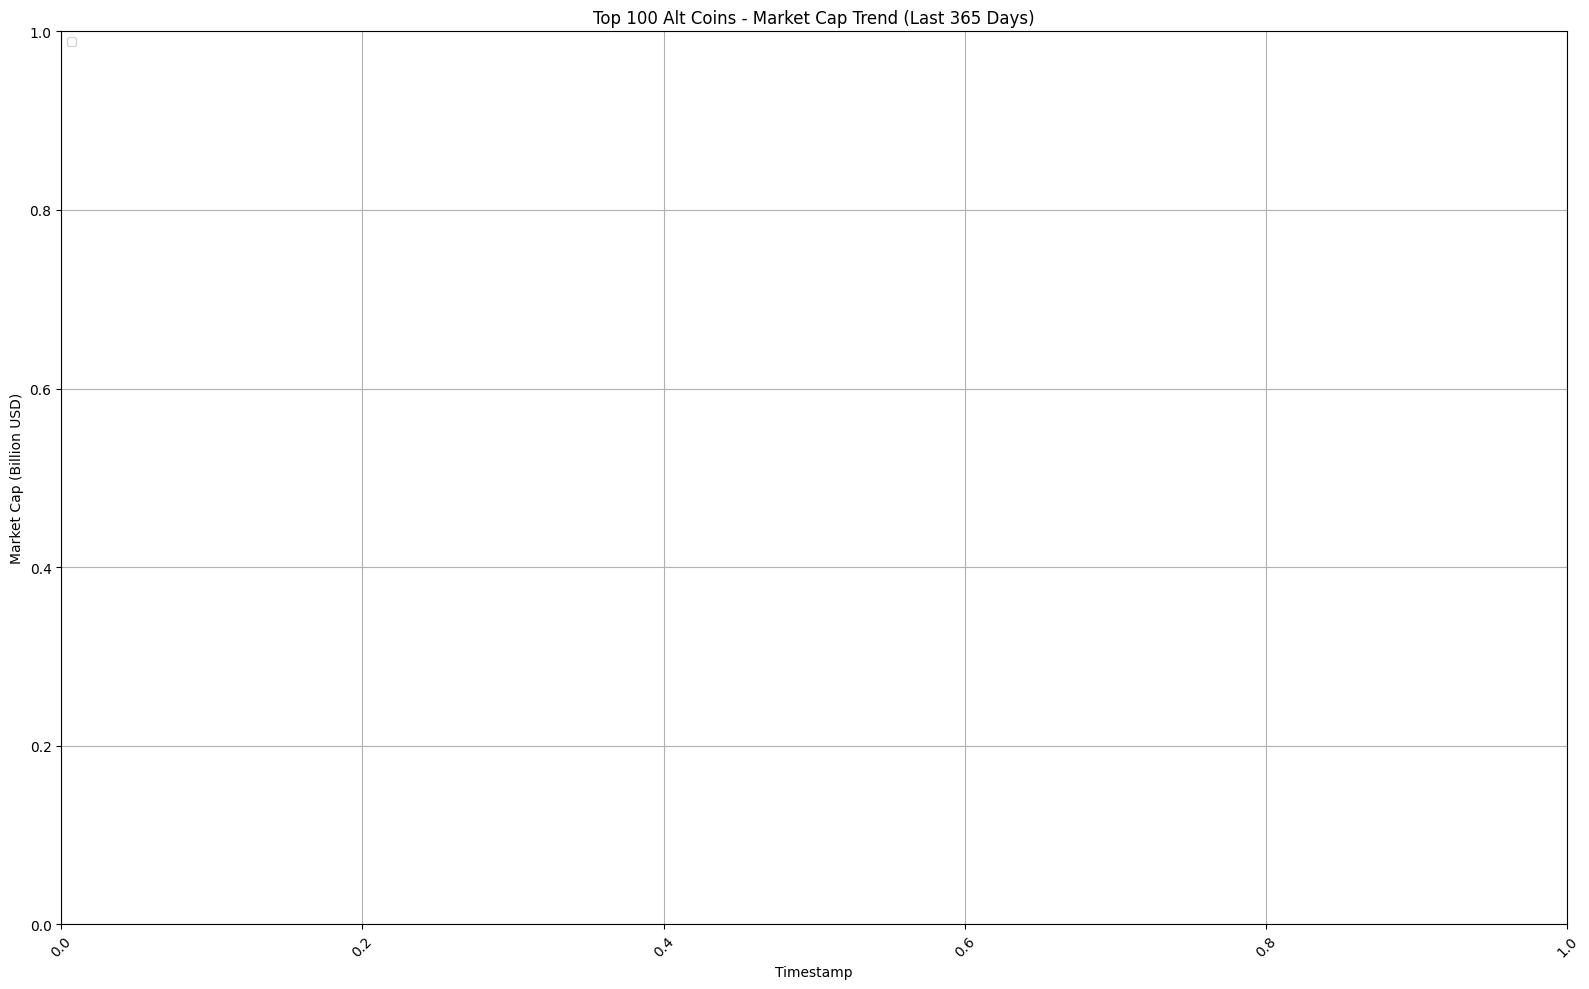

In [9]:
# 최종 가공된 데이터를 시각화
plot_market_caps(coin_market_data)

In [10]:
# get_top_100_coins() 응답 내용(JSON) 확인
coins

[]

In [11]:
# get_market_chart() 응답 내용(JSON) 확인
market_caps

NameError: name 'market_caps' is not defined

In [4]:
!pip install librosa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 2.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 2.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 3.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 2.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [librosa]2/13 [librosa]earn]

[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [11]:
import os

print("현재 실행 위치:", os.getcwd())
print("현재 폴더 파일:", os.listdir())

print("상위 폴더 파일:", os.listdir(".."))
print("data 폴더 파일:", os.listdir("../data"))

print("파일 존재 여부:", os.path.exists("../data/abnorm_1.wav"))

현재 실행 위치: /workspaces/bigdata-spark-lab/notebooks/.ipynb_checkpoints
현재 폴더 파일: ['01_numpy_arrays-checkpoint.ipynb', '01_numpy_arrays.ipynb', '08_web_scraping.ipynb', '09_restful_api_inst.ipynb']
상위 폴더 파일: ['.ipynb_checkpoints']


FileNotFoundError: [Errno 2] No such file or directory: '../data'

/tmp/ipykernel_940/3349400633.py:8: UserWarning: amplitude_to_db was called on complex input so phase information will be discarded. To suppress this warning, call amplitude_to_db(np.abs(S)) instead.
  D = librosa.amplitude_to_db(librosa.stft(y), ref=np.max)


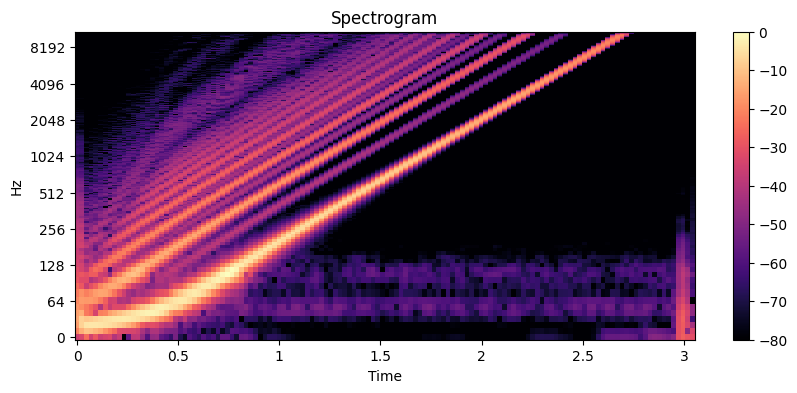

In [12]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

y, sr = librosa.load("../../data/abnorm_1.wav")

D = librosa.amplitude_to_db(librosa.stft(y), ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
plt.colorbar()
plt.title('Spectrogram')
plt.show()

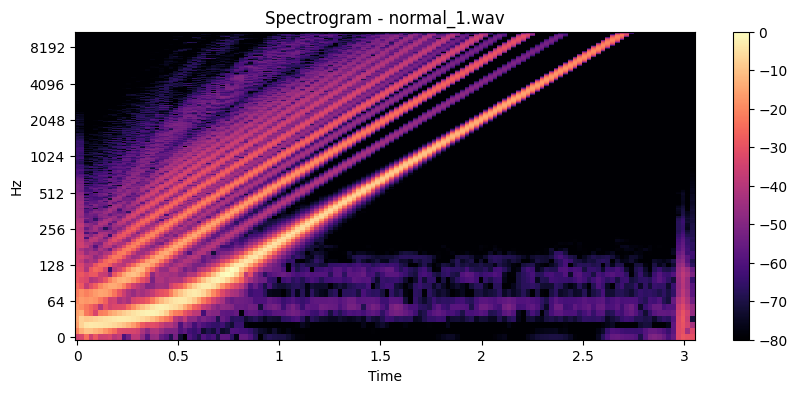

In [15]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

y, sr = librosa.load("../../data/normal_1.wav")

D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
plt.colorbar()
plt.title('Spectrogram - normal_1.wav')
plt.show()